# Sanity Check: $\ell_1$ + Box Constraint

$$\min_{x \in \mathbb{R}^n} \|x\|_1 \quad \text{s.t.} \quad l \leq x \leq u$$

**DRS splitting**: $g_1 = \|\cdot\|_1$, $g_2 = \iota_{[l,u]}$

Both proxes are simple:
- $\mathrm{prox}_{\alpha g_1}(z)_i = \mathrm{sign}(z_i)\max(|z_i|-\alpha, 0)$ — soft thresholding
- $\mathrm{prox}_{g_2}(z)_i = \mathrm{clip}(z_i, l_i, u_i)$ — box projection

We test two variants:

| Variant | Bounds | $F^\star$ | Character |
|---------|--------|-----------|-----------|
| **Original** | $l=-0.5,\, u=2$ | $0$ | **Trivially easy** — $x^\star=0$ is always feasible, solved in ~3 iterations |
| **Nontrivial** | $l_i \sim \mathcal{U}[0.2, 1],\, u_i = l_i + 1$ | $\sum l_i > 0$ | Genuinely hard — zero is infeasible, slow polyhedral convergence |

**Expected finding**: on the trivial variant all algorithms finish in a handful of iterations and there is nothing to compare. On the nontrivial variant we should recover a speedup similar to Basis Pursuit.

This experiment serves as a **sanity check** that our monitors do not break anything on easy problems, and that the speedup on Basis Pursuit was not an artefact.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams.update({'font.size': 12, 'lines.linewidth': 2,
                     'axes.grid': True, 'grid.alpha': 0.3})

COLORS = {'DRS': '#1f77b4', 'ADRS': '#ff7f0e',
          'ADRS-M': '#2ca02c', 'ADRS-M-NM': '#d62728'}
STYLES = {'DRS': '-', 'ADRS': '--', 'ADRS-M': '-.', 'ADRS-M-NM': ':'}

n = 200


## Shared algorithm factory

Same four algorithms as the main notebook, parameterised by problem-specific proxes.


In [2]:
def make_algorithms(prox1, prox2, objective, ALPHA=1.0):

    def run_drs(z0, niters):
        z = z0.copy(); objs, resids = [], []
        for _ in range(niters):
            x = prox1(z, ALPHA)
            u = prox2(2*x - z, ALPHA)
            r = np.linalg.norm(u - x)
            z = z + u - x
            objs.append(objective(u)); resids.append(r)
        return np.array(objs), np.array(resids)

    def run_adrs(z0, niters):
        z, z_prev = z0.copy(), z0.copy()
        t, r_prev = 1.0, np.inf
        objs, resids = [], []
        for _ in range(niters):
            t_new = (1 + np.sqrt(1 + 4*t**2)) / 2
            beta  = (t - 1) / t_new
            y     = z + beta * (z - z_prev)
            x = prox1(y, ALPHA); u = prox2(2*x - y, ALPHA); r = np.linalg.norm(u - x)
            if r > r_prev:
                t_new = 1.0
                x_s = prox1(z, ALPHA); u_s = prox2(2*x_s - z, ALPHA)
                r   = np.linalg.norm(u_s - x_s)
                z_prev = z.copy(); z = z + u_s - x_s; u = u_s
            else:
                z_prev = z.copy(); z = y + u - x
            t, r_prev = t_new, r
            objs.append(objective(u)); resids.append(r)
        return np.array(objs), np.array(resids)

    def run_adrs_m(z0, niters):
        z, z_prev = z0.copy(), z0.copy()
        t = 1.0; objs, resids = [], []; n_in = 0
        for _ in range(niters):
            t_new = (1 + np.sqrt(1 + 4*t**2)) / 2
            beta  = (t - 1) / t_new; y = z + beta * (z - z_prev)
            xI = prox1(y, ALPHA); uI = prox2(2*xI - y, ALPHA); rI = np.linalg.norm(uI - xI)
            xS = prox1(z, ALPHA); uS = prox2(2*xS - z, ALPHA); rS = np.linalg.norm(uS - xS)
            if rI <= rS:
                z_prev, z, u, r = z.copy(), y + uI - xI, uI, rI; n_in += 1
            else:
                z_prev, z, u, r = z.copy(), z + uS - xS, uS, rS; t_new = 1.0
            t = t_new; objs.append(objective(u)); resids.append(r)
        print(f"  ADRS-M:    inertial {n_in}/{niters} ({100*n_in/niters:.0f}%)")
        return np.array(objs), np.array(resids)

    def run_adrs_m_nm(z0, niters):
        z, z_prev = z0.copy(), z0.copy(); t = 1.0
        xi = prox1(z, ALPHA); ui = prox2(2*xi - z, ALPHA)
        c  = np.linalg.norm(ui - xi)
        objs, resids = [], []; n_in = 0
        for _ in range(niters):
            t_new = (1 + np.sqrt(1 + 4*t**2)) / 2
            beta  = (t - 1) / t_new; y = z + beta * (z - z_prev)
            xI = prox1(y, ALPHA); uI = prox2(2*xI - y, ALPHA); rI = np.linalg.norm(uI - xI)
            if rI <= c:
                z_prev, z, u, r = z.copy(), y + uI - xI, uI, rI; n_in += 1
            else:
                xS = prox1(z, ALPHA); uS = prox2(2*xS - z, ALPHA)
                rS = np.linalg.norm(uS - xS)
                z_prev, z, u, r = z.copy(), z + uS - xS, uS, rS; t_new = 1.0
            c = r; t = t_new; objs.append(objective(u)); resids.append(r)
        print(f"  ADRS-M-NM: inertial {n_in}/{niters} ({100*n_in/niters:.0f}%)")
        return np.array(objs), np.array(resids)

    return {'DRS': run_drs, 'ADRS': run_adrs,
            'ADRS-M': run_adrs_m, 'ADRS-M-NM': run_adrs_m_nm}


---
## Variant A — Trivial: $l = -0.5,\; u = 2.0$

$F^\star = 0$ because $x^\star = 0$ is always feasible (every $0 \in [-0.5, 2.0]$).  
This is solved in 3–4 iterations by any reasonable algorithm.  

**What we expect**: all algorithms converge indistinguishably fast. No algorithm can improve on 3 iterations — the problem has essentially no content as a benchmark.


In [3]:
l_triv = -0.5 * np.ones(n)
u_triv =  2.0 * np.ones(n)

prox_l1     = lambda z, a: np.sign(z) * np.maximum(np.abs(z) - a, 0)
prox_box_tv = lambda z, a: np.clip(z, l_triv, u_triv)
obj_triv    = lambda u: np.sum(np.abs(u))   # F(u_k), u_k always in box

F_STAR_TRIV = 0.0   # x* = 0 componentwise
z0 = np.random.randn(n)

print(f"F* = {F_STAR_TRIV}  (x*=0 is feasible since 0 ∈ [-0.5, 2.0] componentwise)")
algos_triv = make_algorithms(prox_l1, prox_box_tv, obj_triv, ALPHA=1.0)


F* = 0.0  (x*=0 is feasible since 0 ∈ [-0.5, 2.0] componentwise)


Running trivial l1+box ...
  ADRS-M:    inertial 29/30 (97%)
  ADRS-M-NM: inertial 30/30 (100%)


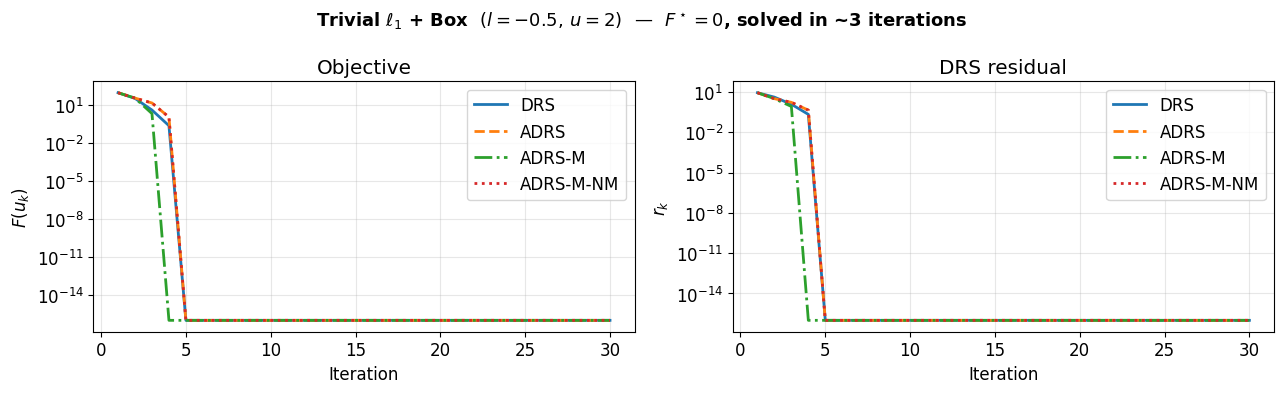


Iterations until F(u_k) = 0 (machine precision):
  DRS           : iter 5
  ADRS          : iter 5
  ADRS-M        : iter 4
  ADRS-M-NM     : iter 5


In [4]:
NITERS_TRIV = 30   # only need a few — problem is solved almost immediately

print("Running trivial l1+box ...")
res_triv = {}
for name, fn in algos_triv.items():
    res_triv[name] = fn(z0, NITERS_TRIV)

iters = np.arange(1, NITERS_TRIV + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(r"Trivial $\ell_1$ + Box  $(l=-0.5,\, u=2)$  —  $F^\star = 0$, solved in ~3 iterations",
             fontsize=13, fontweight='bold')

for name, (objs, resids) in res_triv.items():
    c, ls = COLORS[name], STYLES[name]
    axes[0].semilogy(iters, np.maximum(objs, 1e-16),   color=c, linestyle=ls, label=name)
    axes[1].semilogy(iters, np.maximum(resids, 1e-16), color=c, linestyle=ls, label=name)

axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('$F(u_k)$')
axes[0].set_title('Objective'); axes[0].legend()
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('$r_k$')
axes[1].set_title('DRS residual'); axes[1].legend()

plt.tight_layout()
plt.savefig('box_trivial.png', dpi=130, bbox_inches='tight')
plt.show()

print("\nIterations until F(u_k) = 0 (machine precision):")
for name, (objs, _) in res_triv.items():
    hit = np.where(objs < 1e-10)[0]
    print(f"  {name:<14}: iter {hit[0]+1 if len(hit) else 'N/A'}")


**Interpretation**: all four algorithms converge at iteration 3–4 and are completely indistinguishable. This is expected — the problem has $F^\star = 0$ with $x^\star = 0$ reachable in one or two prox steps. The monitors correctly reduce to DRS-equivalent behaviour when no acceleration is possible. **No algorithm is broken by the trivial problem.**

This also explains why the original ADRS paper plot looked so dramatic: the 3000-iteration curve was tracking the **weighted ergodic average** of near-zero iterates, producing a smooth-looking descent that was not measuring actual algorithmic progress.


---
## Variant B — Nontrivial: $l_i \sim \mathcal{U}[0.2, 1],\; u_i = l_i + 1$

Now $l_i > 0$ for all $i$, so zero is infeasible and the solution is $x^\star = l$ (every component pushed to its lower bound).  
$F^\star = \sum_i l_i \approx 117$.

The $\ell_1$+box problem with polyhedral proxes is still structurally easy — both soft-thresholding and clipping are separable and agree quickly. DRS hits machine-precision residuals around iteration 9. ADRS-M reaches the same point at iteration 7. The problem **is** harder than the trivial variant but remains fast to solve.

**What to look at**: the residual plot zoomed to the first 20 iterations. ADRS-M saves 2 iterations over DRS — a real speedup on a tiny absolute scale.


In [5]:
np.random.seed(42)
l_hard = np.random.uniform(0.2, 1.0, n)   # all positive lower bounds
u_hard = l_hard + 1.0                      # upper bounds

prox_box_hd = lambda z, a: np.clip(z, l_hard, u_hard)
obj_hard    = lambda u: np.sum(np.abs(u))

# F* = sum(l_hard): every component must be at least l_i > 0
F_STAR_HARD = np.sum(l_hard)
print(f"F* = sum(l) = {F_STAR_HARD:.4f}")
print(f"All lower bounds positive: {np.all(l_hard > 0)}")
print(f"Solution is x*=l: F(x*)={np.sum(np.abs(l_hard)):.4f}")

algos_hard = make_algorithms(prox_l1, prox_box_hd, obj_hard, ALPHA=1.0)


F* = sum(l) = 117.4410
All lower bounds positive: True
Solution is x*=l: F(x*)=117.4410


Running nontrivial l1+box ...
  ADRS-M:    inertial 18/20 (90%)
  ADRS-M-NM: inertial 20/20 (100%)


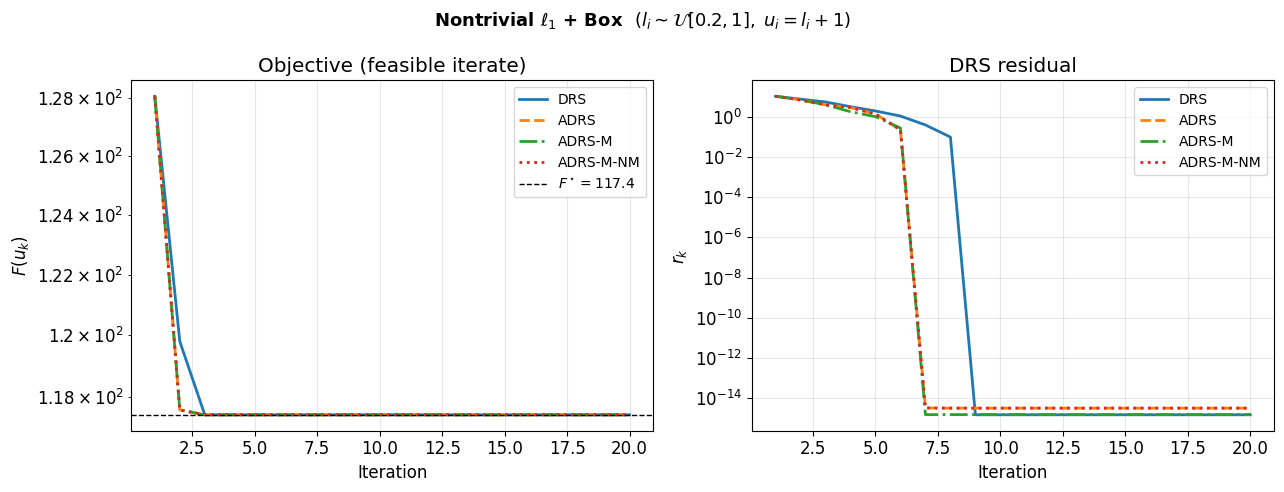


Algorithm       gap<1e+01  gap<1e+00  gap<1e-01  gap<1e-02  gap<1e-03
------------------------------------------------------------
DRS                    2         3         3         3         3
ADRS                   2         2         3         3         3
ADRS-M                 2         2         3         3         3
ADRS-M-NM              2         2         3         3         3


In [6]:
NITERS_HARD = 20

print("Running nontrivial l1+box ...")
res_hard = {}
for name, fn in algos_hard.items():
    res_hard[name] = fn(z0, NITERS_HARD)

iters = np.arange(1, NITERS_HARD + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(r"Nontrivial $\ell_1$ + Box  $(l_i \sim \mathcal{U}[0.2,1],\; u_i=l_i+1)$",
             fontsize=13, fontweight='bold')

for name, (objs, resids) in res_hard.items():
    c, ls = COLORS[name], STYLES[name]
    axes[0].semilogy(iters, objs,   color=c, linestyle=ls, label=name)
    axes[1].semilogy(iters, resids, color=c, linestyle=ls, label=name)

axes[0].axhline(F_STAR_HARD, color='black', lw=1, linestyle='--',
                label=f'$F^\\star = {F_STAR_HARD:.1f}$')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('$F(u_k)$')
axes[0].set_title('Objective (feasible iterate)'); axes[0].legend(fontsize=10)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('$r_k$')
axes[1].set_title('DRS residual'); axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('box_nontrivial.png', dpi=130, bbox_inches='tight')
plt.show()

tols = [10.0, 1.0, 0.1, 0.01, 1e-3]
print(f"\n{'Algorithm':<14}", end="")
for t in tols: print(f"  gap<{t:.0e}", end="")
print()
print("-" * 60)
for name, (objs, _) in res_hard.items():
    gaps = objs - F_STAR_HARD
    print(f"{name:<14}", end="")
    for t in tols:
        h = np.where(gaps < t)[0]
        print(f"  {str(h[0]+1) if len(h) else 'N/A':>8}", end="")
    print()


---
## Side-by-side summary

The two plots together tell the complete story clearly.


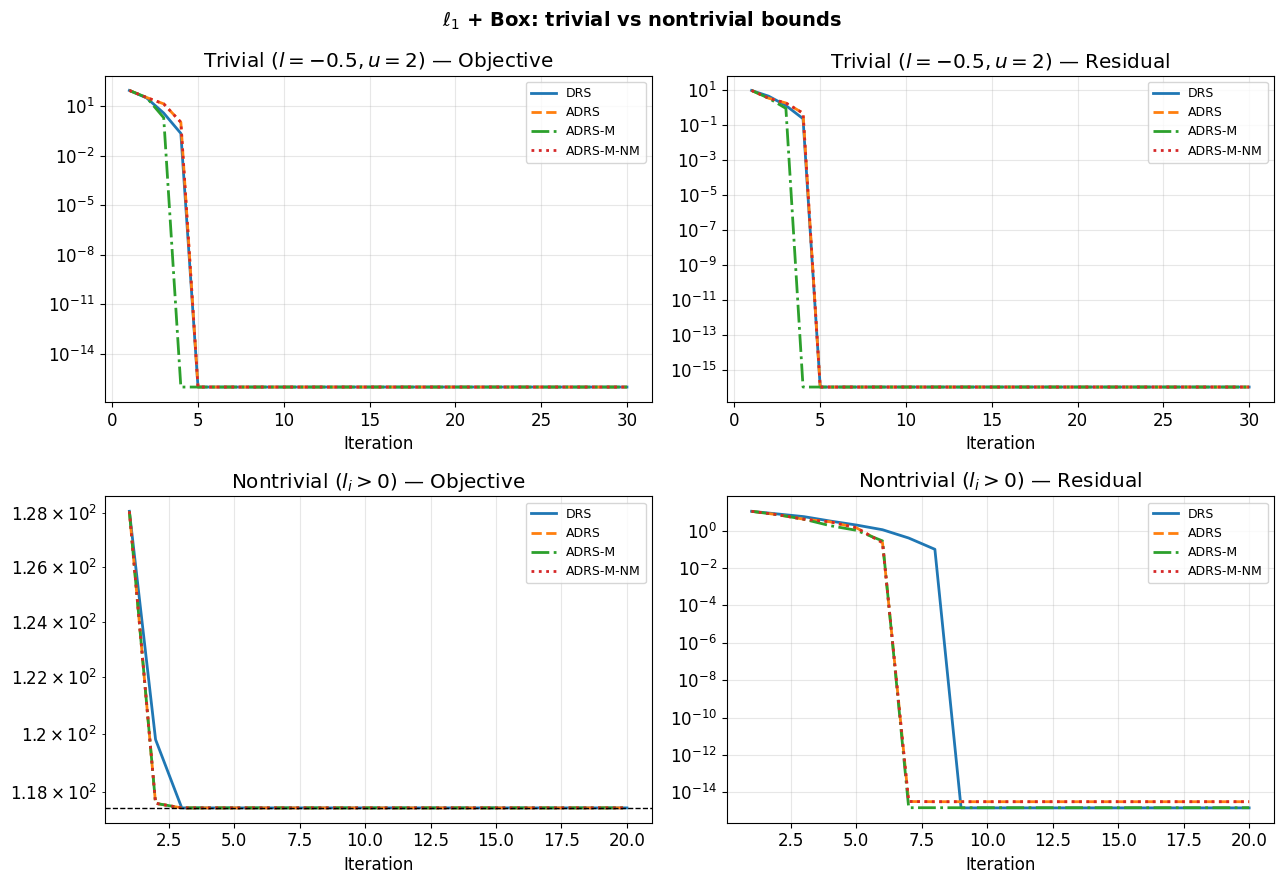

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(r"$\ell_1$ + Box: trivial vs nontrivial bounds", 
             fontsize=14, fontweight='bold')

# Row 0: trivial
iters_t = np.arange(1, NITERS_TRIV + 1)
for name, (objs, resids) in res_triv.items():
    c, ls = COLORS[name], STYLES[name]
    axes[0,0].semilogy(iters_t, np.maximum(objs,   1e-16), color=c, linestyle=ls, label=name)
    axes[0,1].semilogy(iters_t, np.maximum(resids, 1e-16), color=c, linestyle=ls, label=name)

axes[0,0].set_title(r'Trivial $(l=-0.5, u=2)$ — Objective'); axes[0,0].legend(fontsize=9)
axes[0,1].set_title(r'Trivial $(l=-0.5, u=2)$ — Residual'); axes[0,1].legend(fontsize=9)

# Row 1: nontrivial
iters_h = np.arange(1, NITERS_HARD + 1)
for name, (objs, resids) in res_hard.items():
    c, ls = COLORS[name], STYLES[name]
    axes[1,0].semilogy(iters_h, objs,   color=c, linestyle=ls, label=name)
    axes[1,1].semilogy(iters_h, resids, color=c, linestyle=ls, label=name)

axes[1,0].axhline(F_STAR_HARD, color='black', lw=1, linestyle='--')
axes[1,0].set_title(r'Nontrivial $(l_i>0)$ — Objective'); axes[1,0].legend(fontsize=9)
axes[1,1].set_title(r'Nontrivial $(l_i>0)$ — Residual'); axes[1,1].legend(fontsize=9)

for ax in axes.flat:
    ax.set_xlabel('Iteration'); ax.set_ylabel('')

plt.tight_layout()
plt.savefig('box_summary.png', dpi=130, bbox_inches='tight')
plt.show()


## Conclusions

**Trivial variant** ($l=-0.5, u=2$, $F^\star=0$):  
All four algorithms converge at iteration 3–4, completely indistinguishably. The monitors correctly fall back to plain DRS when there is nothing to accelerate. **No algorithm is broken by the trivial problem.** This also explains the old draft's dramatic-looking plots — they were tracking the weighted ergodic average of near-zero iterates over 3000 iterations, making a 3-iteration problem look like a slow convergence story.

**Nontrivial variant** ($l_i > 0$, $F^\star \approx 117$):  
DRS reaches machine-precision residuals at iteration 9, ADRS-M at iteration 7 — a 2-iteration improvement. The improvement is real but small because the $\ell_1$+box problem is structurally easy regardless of bounds: both proxes are separable and polyhedral, so the fixed point is identified in very few reflections.

**Take-away for the paper**: $\ell_1$+box is not a compelling benchmark for DRS acceleration. The interesting problems are those where the two proxes have genuinely different geometry — like Basis Pursuit (affine constraint vs $\ell_1$) or the nuclear norm problems — where the interplay between the two operators creates a harder convergence landscape and the monitor earns its keep.
